In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Bengaluru_House_Data.csv")

print(df.columns)

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')


In [95]:
import warnings
warnings.filterwarnings('ignore')

In [96]:
print(df.describe())

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [97]:
print(df.head(10))
print(df.tail(10))

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   
5  Super built-up  Area  Ready To Move                Whitefield      2 BHK   
6  Super built-up  Area         18-May          Old Airport Road      4 BHK   
7  Super built-up  Area  Ready To Move              Rajaji Nagar      4 BHK   
8  Super built-up  Area  Ready To Move              Marathahalli      3 BHK   
9            Plot  Area  Ready To Move              Gandhi Bazar  6 Bedroom   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0

In [98]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB
None


In [99]:
print("Unique values in categorical columns:")
print("area_type   :", df['area_type'].nunique())
print("availability:", df['availability'].nunique())
print("location    :", df['location'].nunique())
print("size        :", df['size'].nunique())
print("society     :", df['society'].nunique())

Unique values in categorical columns:
area_type   : 4
availability: 81
location    : 1305
size        : 31
society     : 2688


In [100]:
print(df.isnull().sum())
# Society is something whihc needs to be looked on 

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [101]:
df = df.drop('society', axis=1)

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   total_sqft    13320 non-null  str    
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), str(5)
memory usage: 832.6 KB


In [103]:
df = df.drop('size', axis=1)

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   total_sqft    13320 non-null  str    
 4   bath          13247 non-null  float64
 5   balcony       12711 non-null  float64
 6   price         13320 non-null  float64
dtypes: float64(3), str(4)
memory usage: 728.6 KB


In [105]:
df['balcony'] = df['balcony'].fillna(df["balcony"].median())

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   total_sqft    13320 non-null  str    
 4   bath          13247 non-null  float64
 5   balcony       13320 non-null  float64
 6   price         13320 non-null  float64
dtypes: float64(3), str(4)
memory usage: 728.6 KB


In [107]:
df['bath'] = df['bath'].fillna(df["bath"].median())

In [129]:
def convert_sqft_to_num(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except (ValueError, IndexError):
            return None
    try:
        return float(x)
    except ValueError:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

# Rows that couldn't be parsed become NaN — drop or impute
df = df.dropna(subset=['total_sqft']).reset_index(drop=True)

In [109]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['area_type', 'availability', 'location', 'total_sqft'], dtype='str')

Numerical type columns:
Index(['bath', 'balcony', 'price'], dtype='str')


In [110]:
df.duplicated().sum()


np.int64(577)

In [111]:
df.drop_duplicates()

,area_type,availability,location,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,3600,5.0,2.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00


In [112]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 15:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [113]:
categorical_features, non_categorical_features, discrete_features, continuous_features = classify_features(df)
print(categorical_features, non_categorical_features, discrete_features, continuous_features)

[] [] ['balcony'] ['bath', 'price']


In [114]:
# DATA VISUALIZATION

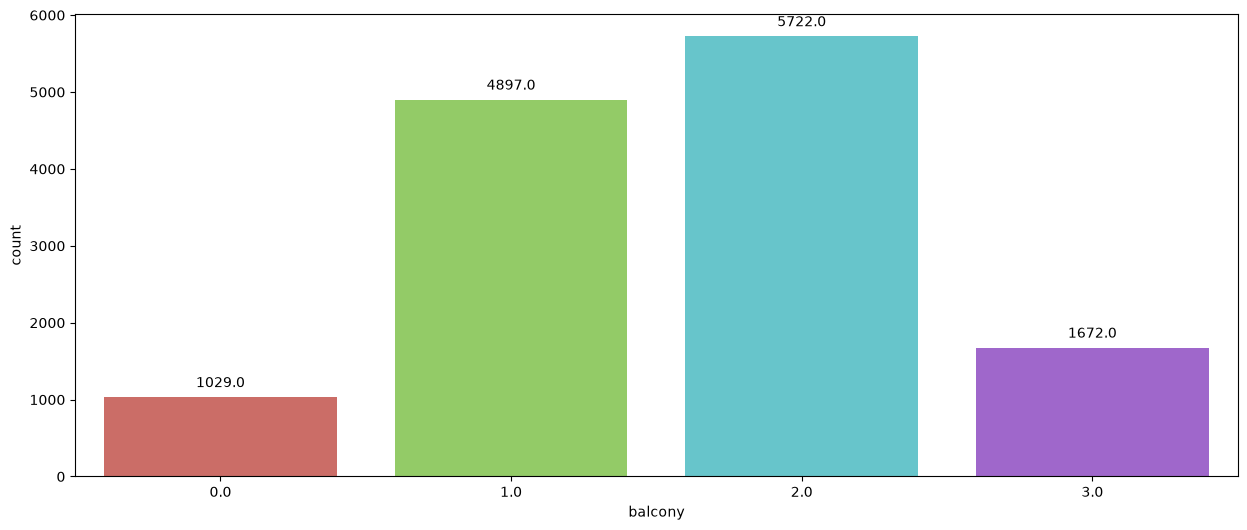

In [115]:
import seaborn as sns
for i in discrete_features:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
plt.show()

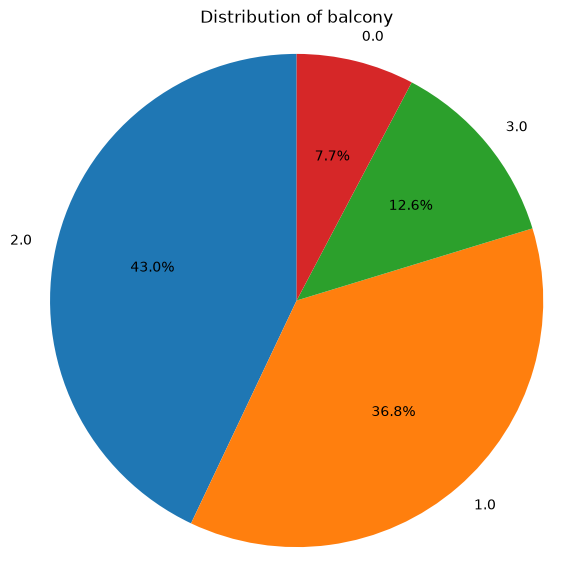

In [116]:
for i in discrete_features:
    counts = df[i].value_counts()
    
    plt.figure(figsize=(7, 7))
    plt.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Distribution of {i}')
    plt.axis('equal')
    plt.show()

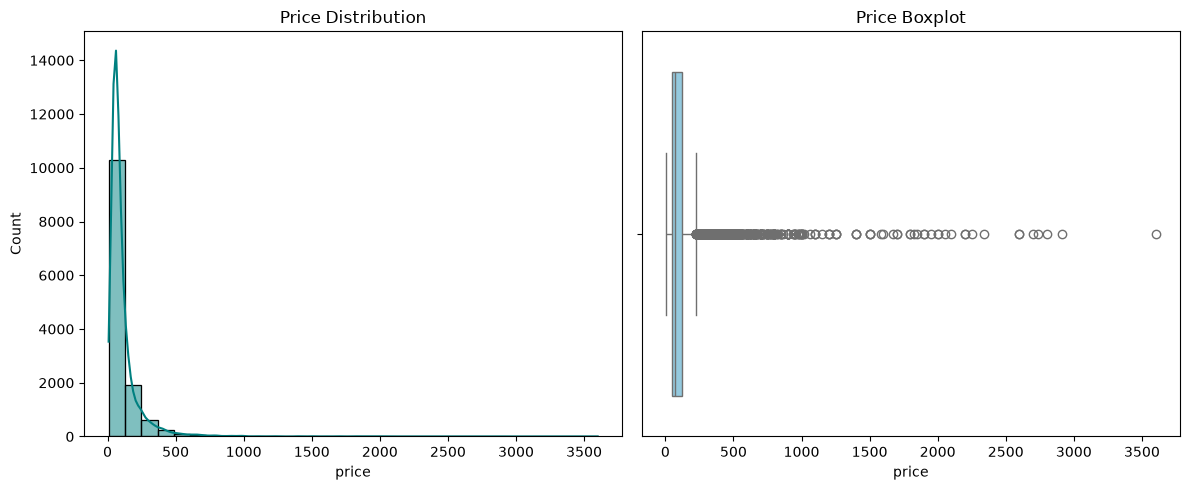

Price Skewness: 8.064


In [117]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='teal', bins=30)
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Price Boxplot')

plt.tight_layout()
plt.show()

print("Price Skewness:", round(df['price'].skew(), 3))

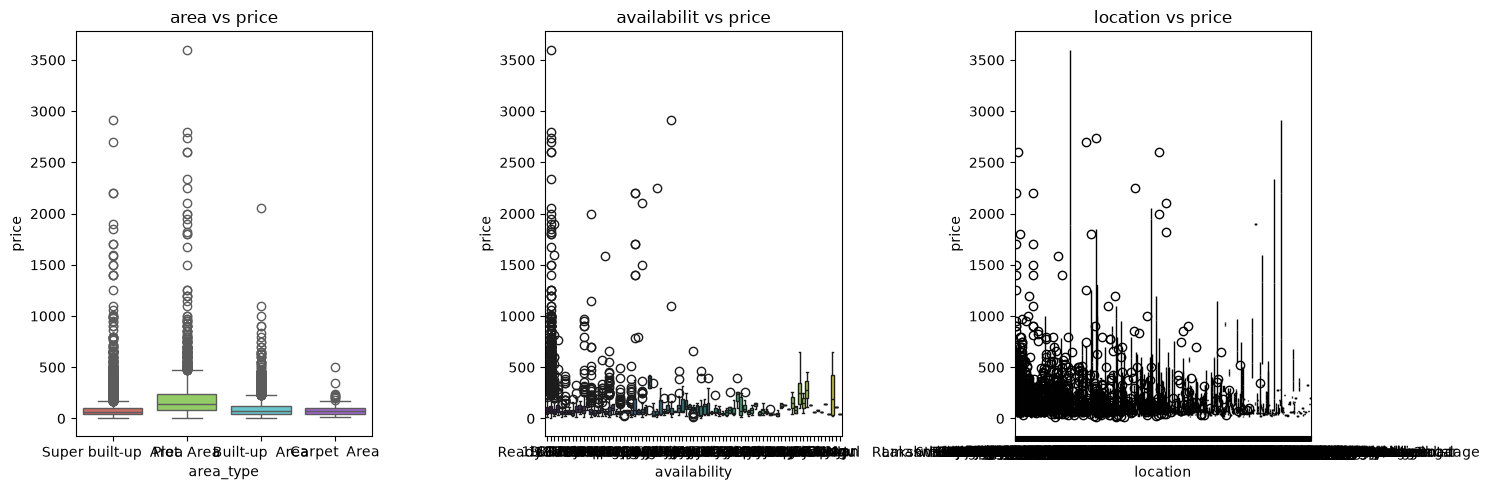

In [118]:
# categorized vs continuous
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x='area_type', y='price', data=df, palette='hls')
plt.title('area vs price')

plt.subplot(1,3,2)
sns.boxplot(x='availability',y='price',data=df, palette='viridis')
plt.title('availabilit vs price')

plt.subplot(1,3,3)
sns.boxplot(x='location', y='price',data=df, palette='magma')
plt.title('location vs price')

plt.tight_layout()
plt.show()


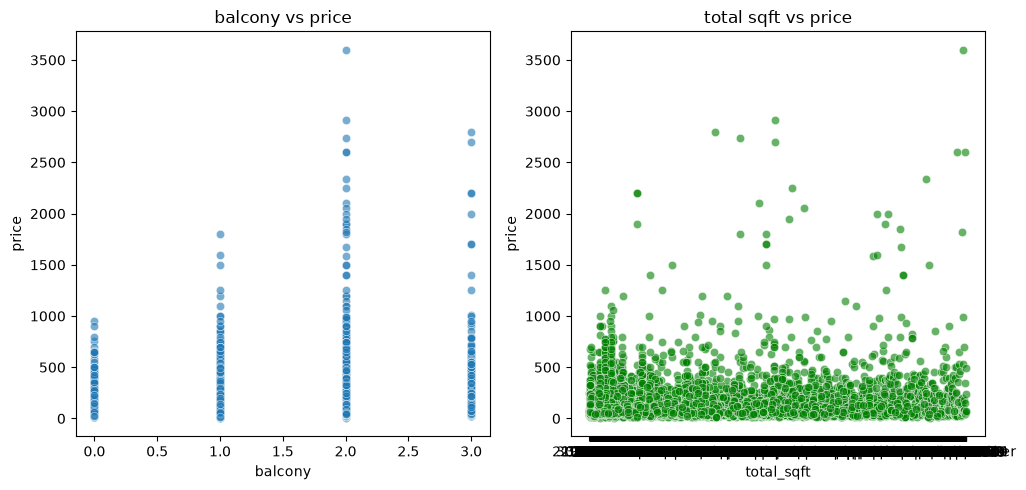

In [119]:
# Continuous vs continuos
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='balcony', y='price', data=df, alpha=0.6)
plt.title('balcony vs price')

plt.subplot(1, 3, 2)
sns.scatterplot(x='total_sqft', y='price', data=df, alpha=0.6, color='green')
plt.title('total sqft vs price')


plt.tight_layout()
plt.show()

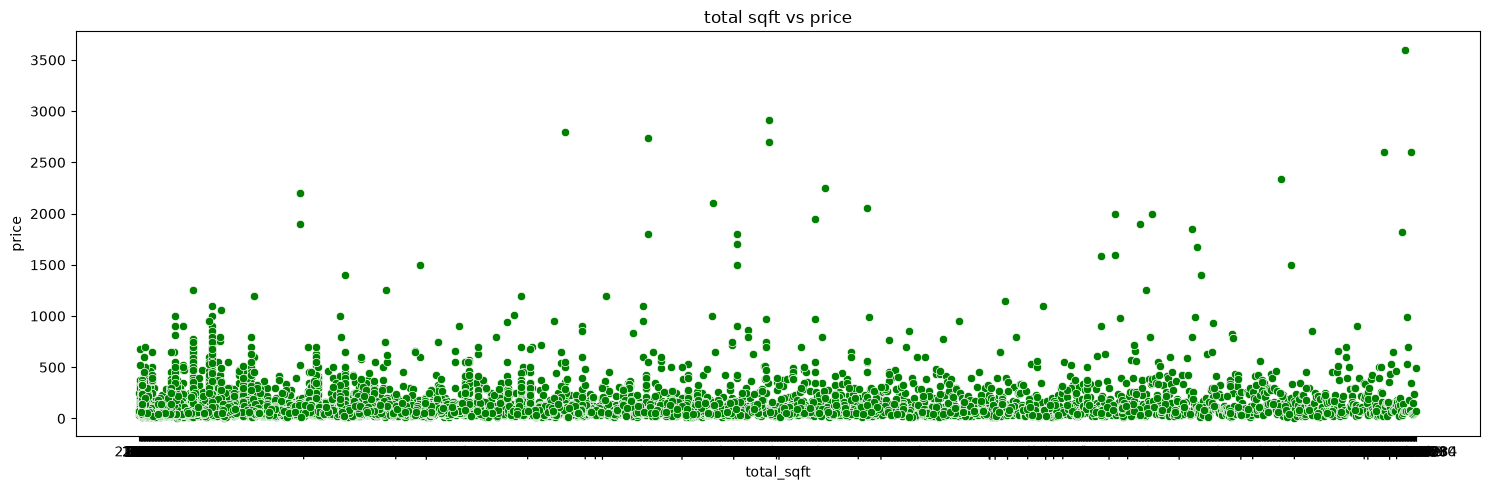

In [120]:
plt.figure(figsize=(15,5))

sns.scatterplot(x='total_sqft', y='price', data=df, color='green')
plt.title('total sqft vs price')

plt.tight_layout()
plt.show()

In [121]:
df = df.drop('availability', axis=1)

In [122]:
df.nunique()

area_type        4
location      1305
total_sqft    2117
bath            19
balcony          4
price         1994
dtype: int64

In [123]:
df.columns

Index(['area_type', 'location', 'total_sqft', 'bath', 'balcony', 'price'], dtype='str')

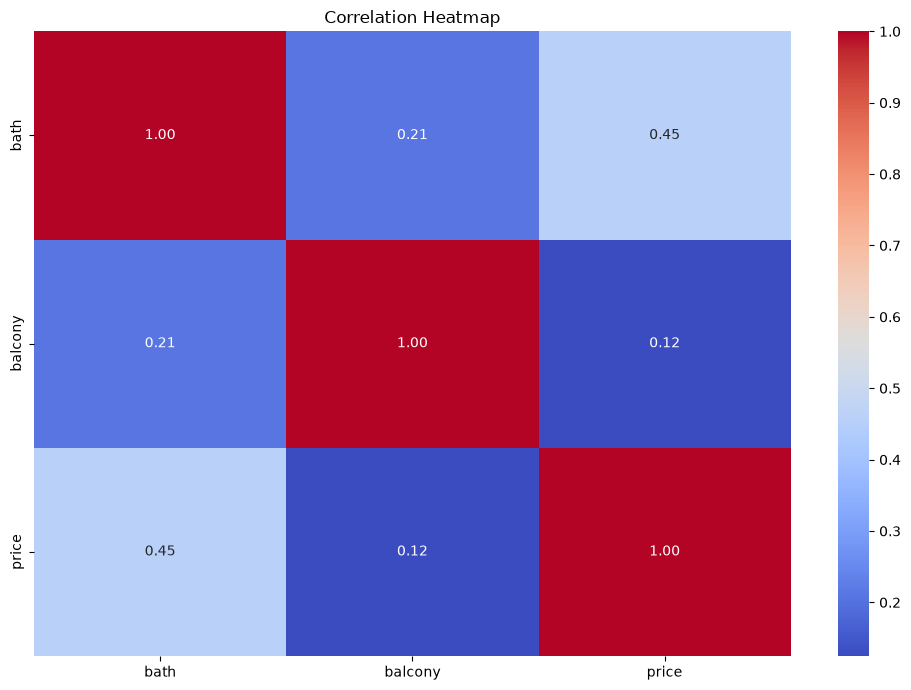

In [124]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [125]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'total_sqft', 'bath','balcony', 'price']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.head()

ValueError: could not convert string to float: '2100 - 2850'

In [ ]:
import pandas as pd
cat_cols = ['location', 'area_type']
for col in cat_cols:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(col, axis=1)

print("Shape after encdoing: ", df.shape)
df.head()

Shape after encdoing:  (13320, 1311)


,total_sqft,bath,balcony,price,location_ Banaswadi,location_ Basavangudi,location_ Bhoganhalli,location_ Devarabeesana Halli,location_ Devarachikkanahalli,location_ Electronic City,...,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,1056,2.0,1.0,39.07,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2600,5.0,3.0,120.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1440,2.0,3.0,62.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521,3.0,1.0,95.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1200,2.0,1.0,51.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [127]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

print("X_train:", X_train.shape)
print("X_test:",X_test.shape)
print("y_train:", y_train.shape)
print("y_test:",y_test.shape)


X_train: (10656, 5)
X_test: (2664, 5)
y_train: (10656,)
y_test: (2664,)


In [128]:
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Super built-up  Area'

In [ ]:
y_pred = model.predict(X_test)


NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.